# Learned adaptive gate, and the final comparison

**RQ4** Can a learned gate exploit inference-time information better than
confidence thresholding?

Architecture, kept binary deliberately:

```
   GPS  (0.39 GFLOPs)
     │
     ├── features ──> learned gate ──> STOP
     │                      │
     │                      └────────> + Camera (48.24 GFLOPs) ──> final beam
```

**Why binary and not multi-class.** The ablation gives camera +0.154 DBA over
GPS against LiDAR's +0.047 and radar's +0.050, and GPS + Camera is the single
best configuration overall, so camera is the only escalation worth a route. One
caveat is recorded rather than acted on: on the *unseen* scenario 31, GPS+LiDAR
(0.2240 DBA) beat GPS+Camera (0.0200), which would argue for a LiDAR route — but
that rests on 50 samples, so `ROUTES` is left configurable and the third route
is off by default.

**The gate runs after the cheap model**, because its most informative feature is
that model's own uncertainty, and the cheap model costs 0.8 % of the expensive
one. Gating before any encoder would discard the single best signal to save
almost nothing.

## Training

Features come from the **train** split; the gate is evaluated on **val**. The
gate never sees a label, a power vector, or any correctness indicator — those
build the target only.

Two formulations are compared, because the right one depends on the class
balance the oracle run reported (escalation pays 22.9 %, hurts 8.9 %, neither
45 %):

1. **Classification** of "escalation pays", with positive weighting.
2. **Regression on the per-sample DBA gain.** Preferred a priori: it handles
   the 45 % where escalation is useless and the 8.9 % where it is harmful as
   small and negative targets rather than forcing them into one negative class,
   and thresholding a predicted gain is exactly the cost-aware decision
   `gain > λ·cost`.

## 1. Configuration

In [1]:
QUICK_RUN = False
CHEAP, EXPENSIVE = "gps", "gps_image"
ROUTES = [CHEAP, EXPENSIVE]          # add "gps_lidar" only if justified
TRAIN_SPLIT, EVAL_SPLIT = "train", "val"
BATCH_SIZE = 32
WORKERS = 2
COLLECT_SENSOR_QUALITY = True
GATE_EPOCHS = 300

LIMIT_TRAIN = 400 if QUICK_RUN else None
LIMIT_EVAL = 300 if QUICK_RUN else None
from pathlib import Path
OUT = Path("/kaggle/working/outputs/adaptive_gate")
FINAL = Path("/kaggle/working/outputs/adaptive_final")
for d in (OUT / "plots", FINAL / "plots"):
    d.mkdir(parents=True, exist_ok=True)
print(f"QUICK_RUN={QUICK_RUN}  train limit={LIMIT_TRAIN}  eval limit={LIMIT_EVAL}")

QUICK_RUN=False  train limit=None  eval limit=None


In [2]:
import os
import socket
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print(f"torch {torch.__version__}   cuda: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_properties(0).name}")


def has_internet(host="github.com", port=443, timeout=6):
    try:
        socket.create_connection((host, port), timeout=timeout).close()
        return True
    except OSError:
        return False


assert has_internet(), "Internet is off; the code cannot be cloned."

torch 2.11.0+cu128   cuda: True
GPU: Tesla T4


In [3]:
import shutil

INPUT_ROOT = Path("/kaggle/input")
SOURCES = ("development", "adaptation", "test")


def walk_dirs(base, follow=True):
    for dirpath, dirnames, filenames in os.walk(base, followlinks=follow):
        yield Path(dirpath), dirnames, filenames


def find_source(base, name):
    for c in (base / name / name, base / name):
        if c.is_dir() and any(c.glob("scenario*")):
            return c
    return None


def find_index(base):
    hits = []
    for c in (base / "index" / "index", base / "index"):
        if (c / "samples.csv").exists():
            hits.append(c)
    for d, _dn, fn in walk_dirs(base):
        if "samples.csv" in fn and d not in hits:
            hits.append(d)
    if not hits:
        return None
    # prefer the index that sits beside the actual tensors, not a copy inside a
    # results dump
    score = lambda h: sum(1 for s in SOURCES
                          for r in (h.parent, h.parent.parent, h)
                          if find_source(r, s) is not None)
    return sorted(hits, key=score, reverse=True)[0]


INDEX_SRC = find_index(INPUT_ROOT)
assert INDEX_SRC is not None, "samples.csv not found; attach the preprocessed dataset"
ROOTS = [INDEX_SRC.parent, INDEX_SRC.parent.parent, INDEX_SRC]
SOURCE_DIRS = {s: next((d for d in (find_source(r, s) for r in ROOTS) if d), None)
               for s in SOURCES}
for s in [k for k, v in SOURCE_DIRS.items() if v is None]:
    for d, dn, _f in walk_dirs(INPUT_ROOT):
        if d.name == s and any(x.startswith("scenario") for x in dn):
            SOURCE_DIRS[s] = d
            break

# stage idempotently: /kaggle/working survives between cell runs
STAGE_DIR = Path("/kaggle/working/data/processed_amber")
STAGE_DIR.mkdir(parents=True, exist_ok=True)
INDEX_DIR = STAGE_DIR / "index"
staged, src_csv = INDEX_DIR / "samples.csv", INDEX_SRC / "samples.csv"
if not staged.exists():
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
elif staged.stat().st_size != src_csv.stat().st_size:
    shutil.rmtree(INDEX_DIR)
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
for name, src in SOURCE_DIRS.items():
    if src is None:
        continue
    link = STAGE_DIR / name
    if link.is_symlink():
        try:
            same = link.resolve(strict=True) == src.resolve(strict=True)
        except OSError:
            same = False
        if not same:
            link.unlink()
    elif link.exists():
        shutil.rmtree(link)
    if not link.exists():
        link.symlink_to(src)
print(f"index {INDEX_DIR}")

index /kaggle/working/data/processed_amber/index


In [4]:
PROJECT = Path("/kaggle/working/project")
if not (PROJECT / "amber" / "model.py").exists():
    r = subprocess.run(["git", "clone", "--depth", "1", "https://github.com/SathishAdithiyaaSV/MultiModal-Beam-Prediction.git", str(PROJECT)],
                       capture_output=True, text=True,
                       env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})
    assert r.returncode == 0, (r.stderr or "")[:400]
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from amber import degrade, quality
from amber.ablation import config_label, enabled_mask, parse_modalities, restrict_availability
from amber.config import MODALITIES, TrainConfig
from amber.dataset import AmberDataset
from amber.degrade import Degradation
from amber.metrics import evaluate
from amber.predict import load_checkpoint
from amber.train import make_loader, pick_device, to_device

GFLOPS = {"gps": 0.3869, "gps_radar": 23.5668, "gps_lidar": 23.0530,
           "gps_radar_lidar": 46.2328, "gps_image": 48.2398,
           "gps_image_lidar": 70.9058, "gps_radar_image": 71.4196,
           "gps_radar_image_lidar": 94.0856}


def find_checkpoints():
    found = {}
    for d, _dn, fn in walk_dirs(INPUT_ROOT):
        if "best.pt" in fn and d.name in GFLOPS:
            found.setdefault(d.name, d / "best.pt")
        for f in fn:
            if f.endswith(".pt") and f[:-3] in GFLOPS:
                found.setdefault(f[:-3], d / f)
    return found


CKPTS = find_checkpoints()
print(f"{len(CKPTS)}/8 checkpoints: {', '.join(sorted(CKPTS))}")
device = pick_device("auto")
train_cfg = TrainConfig()

8/8 checkpoints: gps, gps_image, gps_image_lidar, gps_lidar, gps_radar, gps_radar_image, gps_radar_image_lidar, gps_radar_lidar


In [5]:
import gc
import json
import time

_MODEL_CACHE = {}


def get_model(slug):
    '''Load once and keep -- several sweeps reuse the same checkpoint.'''
    if slug not in _MODEL_CACHE:
        if len(_MODEL_CACHE) >= 2:          # keep GPU memory bounded
            _MODEL_CACHE.clear()
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()
        _MODEL_CACHE[slug] = load_checkpoint(CKPTS[slug], device)
    return _MODEL_CACHE[slug]


@torch.no_grad()
def run_eval(slug, split, degradations=(), mask_out=(), limit=None,
             return_per_sample=False, collect_features=False):
    '''Evaluate one checkpoint, optionally with degraded or masked inputs.

    `mask_out` zeroes availability bits at inference -- the eq. (3) mechanism,
    not a retrained model. `degradations` perturb the input tensors.
    '''
    model, cfg = get_model(slug)
    mods = parse_modalities(slug.split("_"))
    ds = AmberDataset(INDEX_DIR, split, cfg, modalities=mods,
                      degradations=list(degradations))
    if limit:
        from torch.utils.data import Subset
        idx = np.linspace(0, len(ds) - 1, min(limit, len(ds))).astype(int)
        scen = [ds.scenarios[i] for i in idx]
        sids = [ds.sample_ids[i] for i in idx]
        ds = Subset(ds, idx.tolist())
    else:
        scen, sids = ds.scenarios, ds.sample_ids
    loader = make_loader(ds, BATCH_SIZE, shuffle=False, workers=WORKERS)

    keep = enabled_mask([m for m in mods if m not in mask_out], device) if mask_out \
        else enabled_mask(mods, device)
    logits, targets, feats = [], [], []
    for batch in loader:
        batch = restrict_availability(to_device(batch, device), keep)
        out = model(batch, use_cma=False)
        logits.append(out.logits.float().cpu())
        targets.append(batch["target"].cpu())
        if collect_features:
            feats += quality.batch_features(
                {k: v.cpu() for k, v in batch.items() if torch.is_tensor(v)},
                out.logits.float().cpu(), MODALITIES, COLLECT_SENSOR_QUALITY)
    logits, targets = torch.cat(logits), torch.cat(targets)
    lab = targets >= 0
    m = evaluate(logits[lab], targets[lab], ks=train_cfg.topk,
                 delta=train_cfg.dba_delta)
    if not (return_per_sample or collect_features):
        return m
    ranked = logits.topk(3, dim=1).indices.numpy()
    true = targets.numpy()[:, None]
    best = np.minimum.accumulate(np.abs(ranked - true) / train_cfg.dba_delta,
                                 axis=1).clip(max=1.0)
    per = pd.DataFrame({"sample_id": sids, "scenario": scen,
                        "true_beam": targets.numpy(),
                        "pred_beam": ranked[:, 0],
                        "correct1": (ranked[:, 0] == true[:, 0]).astype(int),
                        "correct3": (ranked[:, :3] == true).any(axis=1).astype(int),
                        "dba": (1.0 - best).mean(axis=1)})
    if collect_features:
        per = pd.concat([per, pd.DataFrame(feats)], axis=1)
    return m, per

## 2. Build the gate's training and evaluation tables

In [6]:
def build_table(split, limit):
    tag = f"{split}{'_quick' if QUICK_RUN else ''}"
    cache = OUT / f"table_{tag}.csv"
    if cache.exists():
        return pd.read_csv(cache)
    _mc, cheap = run_eval(CHEAP, split, limit=limit, collect_features=True)
    _me, exp = run_eval(EXPENSIVE, split, limit=limit, return_per_sample=True)
    exp = exp.rename(columns={"correct1": "exp_correct1", "correct3": "exp_correct3",
                              "dba": "exp_dba"})
    T = cheap.merge(exp[["sample_id", "exp_correct1", "exp_correct3", "exp_dba"]],
                    on="sample_id")
    T["label_escalate"] = ((T.correct1 == 0) & (T.exp_correct1 == 1)).astype(int)
    T["gain_dba"] = T.exp_dba - T.dba
    T.to_csv(cache, index=False)
    return T


missing = [c for c in (CHEAP, EXPENSIVE) if c not in CKPTS]
if missing:
    raise SystemExit(
        f"This notebook needs the {missing} checkpoint(s) and they are not attached.\n"
        f"It runs standalone, but the two tiers are mandatory:\n"
        f"  {CHEAP!r}       the cheap tier (ablation part 1)\n"
        f"  {EXPENSIVE!r}   the escalation target (ablation part 2)\n"
        f"Found: {sorted(CKPTS) or 'none'}.\n"
        f"Any further checkpoints are optional and only enrich the final "
        f"comparison table.")
print(f"required tiers present: {CHEAP}, {EXPENSIVE}")
print(f"optional extras for the comparison table: "
      f"{sorted(set(CKPTS) - {CHEAP, EXPENSIVE}) or 'none'}\n")

TR = build_table(TRAIN_SPLIT, LIMIT_TRAIN)
EV = build_table(EVAL_SPLIT, LIMIT_EVAL)
FEATS = [c for c in TR.columns if c not in (
    "sample_id", "scenario", "true_beam", "pred_beam", "correct1", "correct3", "dba",
    "exp_correct1", "exp_correct3", "exp_dba", "label_escalate", "gain_dba")]
print(f"train {TR.shape}   eval {EV.shape}   {len(FEATS)} features\n")
print("class balance on train:")
print(f"  escalation pays : {TR.label_escalate.mean()*100:5.1f}%")
print(f"  cheap already ok: {TR.correct1.mean()*100:5.1f}%")
print(f"  neither correct : {((TR.correct1==0)&(TR.exp_correct1==0)).mean()*100:5.1f}%")
print(f"  escalation hurts: {((TR.correct1==1)&(TR.exp_correct1==0)).mean()*100:5.1f}%")
print(f"\nmean DBA gain {TR.gain_dba.mean():+.4f}   "
      f"negative for {(TR.gain_dba<0).mean()*100:.1f}% of samples")

required tiers present: gps, gps_image
optional extras for the comparison table: ['gps_image_lidar', 'gps_lidar', 'gps_radar', 'gps_radar_image', 'gps_radar_image_lidar', 'gps_radar_lidar']

train (8844, 43)   eval (2198, 43)   31 features

class balance on train:
  escalation pays :  26.7%
  cheap already ok:  36.2%
  neither correct :  37.1%
  escalation hurts:   5.8%

mean DBA gain +0.1534   negative for 9.2% of samples


## 3. Train the gate

In [7]:
class Gate(torch.nn.Module):
    '''Small MLP. Deliberately small: ~2k parameters against the 48 GFLOPs it
    decides about, so its own cost is negligible in the cost model.'''

    def __init__(self, d_in, hidden=32, out=1):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(d_in, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, out))

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_gate(X, y, objective, epochs=GATE_EPOCHS, lr=1e-3):
    Xt = torch.tensor(X, dtype=torch.float32)
    mu, sd = Xt.mean(0, keepdim=True), Xt.std(0, keepdim=True).clamp(min=1e-6)
    Xn = (Xt - mu) / sd
    yt = torch.tensor(y, dtype=torch.float32)
    g = Gate(Xn.shape[1])
    opt = torch.optim.Adam(g.parameters(), lr=lr, weight_decay=1e-4)
    if objective == "classify":
        pw = torch.tensor([(len(yt) - yt.sum()) / yt.sum().clamp(min=1)])
        lossfn = lambda p, t: torch.nn.functional.binary_cross_entropy_with_logits(
            p, t, pos_weight=pw)
    else:
        lossfn = torch.nn.functional.mse_loss
    for _ in range(epochs):
        opt.zero_grad()
        loss = lossfn(g(Xn), yt)
        loss.backward()
        opt.step()
    g.eval()
    n_par = sum(p.numel() for p in g.parameters())
    return (lambda Z: g((torch.tensor(Z, dtype=torch.float32) - mu) / sd).detach().numpy()), n_par


torch.manual_seed(0)
gates = {}
gates["classify"], npar = train_gate(TR[FEATS].to_numpy(),
                                     TR.label_escalate.to_numpy(), "classify")
gates["regress_gain"], _ = train_gate(TR[FEATS].to_numpy(),
                                      TR.gain_dba.to_numpy(), "regress")
print(f"two gates trained, {npar} parameters each "
      f"({npar*2/1e9:.2e} GFLOPs per decision -- negligible)")

two gates trained, 2113 parameters each (4.23e-06 GFLOPs per decision -- negligible)


## 4. Operating curves

The full curve matters more than any single point. Each gate ranks the
evaluation samples by its escalation score; sweeping the fraction escalated
traces accuracy against average compute.

Cost model: GPS always runs, and escalation adds the camera encoder, so
`cost(f) = 0.39 + f · (48.24 − 0.39)`.

In [8]:
c1, e1 = EV.correct1.to_numpy(), EV.exp_correct1.to_numpy()
cd, ed = EV.dba.to_numpy(), EV.exp_dba.to_numpy()
n = len(EV)
C_LO, C_HI = GFLOPS[CHEAP], GFLOPS[EXPENSIVE]


def sweep(score, name):
    order = np.argsort(-np.asarray(score))      # most-in-need first
    rows = []
    for f in np.linspace(0, 1, 101):
        k = int(round(f * n))
        esc = np.zeros(n, bool)
        esc[order[:k]] = True
        rows.append({"gate": name, "escalated_frac": f,
                     "Top-1": np.where(esc, e1, c1).mean(),
                     "DBA": np.where(esc, ed, cd).mean(),
                     "GFLOPs": C_LO + f * (C_HI - C_LO)})
    return pd.DataFrame(rows)


curves = [sweep(-EV.top1_conf.to_numpy(), "confidence threshold")]
for name, fn in gates.items():
    curves.append(sweep(fn(EV[FEATS].to_numpy()), f"learned gate ({name})"))
# the oracle ceiling, for reference only
curves.append(sweep(((EV.correct1 == 0) & (EV.exp_correct1 == 1)).astype(float).to_numpy()
                    + 1e-6 * EV.gain_dba.to_numpy(), "ORACLE (upper bound)"))
curves = pd.concat(curves, ignore_index=True)
curves.to_csv(OUT / "operating_curves.csv", index=False)

base_dba, base_t1 = ed.mean(), e1.mean()
print(f"always expensive: Top-1 {base_t1:.4f}  DBA {base_dba:.4f}  {C_HI:.2f} GFLOPs\n")
print(f"{'gate':<34}{'esc@DBA-match':>15}{'GFLOPs':>9}{'saved':>8}")
for name, g in curves.groupby("gate", sort=False):
    hit = g[g.DBA >= base_dba]
    if len(hit):
        r = hit.iloc[0]
        print(f"{name:<34}{r.escalated_frac*100:>14.1f}%{r.GFLOPs:>9.2f}"
              f"{(1-r.GFLOPs/C_HI)*100:>7.0f}%")
    else:
        print(f"{name:<34}{'never':>15}{g.DBA.max():>9.4f}{'--':>8}")
print(f"\n{'gate':<34}{'DBA@25%':>9}{'DBA@50%':>9}")
for name, g in curves.groupby("gate", sort=False):
    gr = g.reset_index(drop=True)
    q = lambda f: gr.loc[(gr.escalated_frac - f).abs().idxmin(), "DBA"]
    print(f"{name:<34}{q(.25):>9.4f}{q(.50):>9.4f}")

always expensive: Top-1 0.4604  DBA 0.8835  48.24 GFLOPs

gate                                esc@DBA-match   GFLOPs   saved
confidence threshold                        87.0%    42.02     13%
learned gate (classify)                     84.0%    40.58     16%
learned gate (regress_gain)                 66.0%    31.97     34%
ORACLE (upper bound)                        33.0%    16.18     66%

gate                                DBA@25%  DBA@50%
confidence threshold                 0.8199   0.8557
learned gate (classify)              0.7958   0.8393
learned gate (regress_gain)          0.8372   0.8662
ORACLE (upper bound)                 0.8365   0.9134


## 5. Final comparison

In [9]:
rows = []
for slug in sorted(CKPTS):
    m = run_eval(slug, EVAL_SPLIT, limit=LIMIT_EVAL)
    rows.append({"model": config_label(parse_modalities(slug.split("_"))),
                 "Top-1": m["top1"], "Top-3": m["top3"], "DBA": m["dba"],
                 "GFLOPs": GFLOPS[slug], "escalated_%": np.nan,
                 "avg_modalities": len(slug.split("_"))})
for name, g in curves.groupby("gate", sort=False):
    if "ORACLE" in name:
        continue
    hit = g[g.DBA >= base_dba]
    r = hit.iloc[0] if len(hit) else g.iloc[-1]
    rows.append({"model": f"{name} (DBA-matched)", "Top-1": r["Top-1"], "Top-3": np.nan,
                 "DBA": r.DBA, "GFLOPs": r.GFLOPs,
                 "escalated_%": r.escalated_frac * 100,
                 "avg_modalities": 1 + r.escalated_frac})
    gr = g.reset_index(drop=True)
    r25 = gr.loc[(gr.escalated_frac - .25).abs().idxmin()]
    rows.append({"model": f"{name} @25% escalated", "Top-1": r25["Top-1"], "Top-3": np.nan,
                 "DBA": r25.DBA, "GFLOPs": r25.GFLOPs, "escalated_%": 25.0,
                 "avg_modalities": 1.25})
final = pd.DataFrame(rows).sort_values("DBA", ascending=False)
final.to_csv(FINAL / "final_comparison.csv", index=False)
print(final.round(4).to_string(index=False))

                                     model  Top-1  Top-3    DBA  GFLOPs  escalated_%  avg_modalities
     learned gate (classify) (DBA-matched) 0.4586    NaN 0.8845 40.5833         84.0            1.84
 learned gate (regress_gain) (DBA-matched) 0.4472    NaN 0.8841 31.9698         66.0            1.66
        confidence threshold (DBA-matched) 0.4577    NaN 0.8838 42.0189         87.0            1.87
                              GPS + Camera 0.4604 0.8139 0.8835 48.2398          NaN            2.00
                      GPS + Radar + Camera 0.4431 0.8139 0.8789 71.4196          NaN            3.00
              GPS + Radar + Camera + LiDAR 0.4399 0.8103 0.8759 94.0856          NaN            4.00
                      GPS + Camera + LiDAR 0.4377 0.7962 0.8727 70.9058          NaN            3.00
learned gate (regress_gain) @25% escalated 0.3863    NaN 0.8372 12.3501         25.0            1.25
       confidence threshold @25% escalated 0.3726    NaN 0.8199 12.3501         25.0       

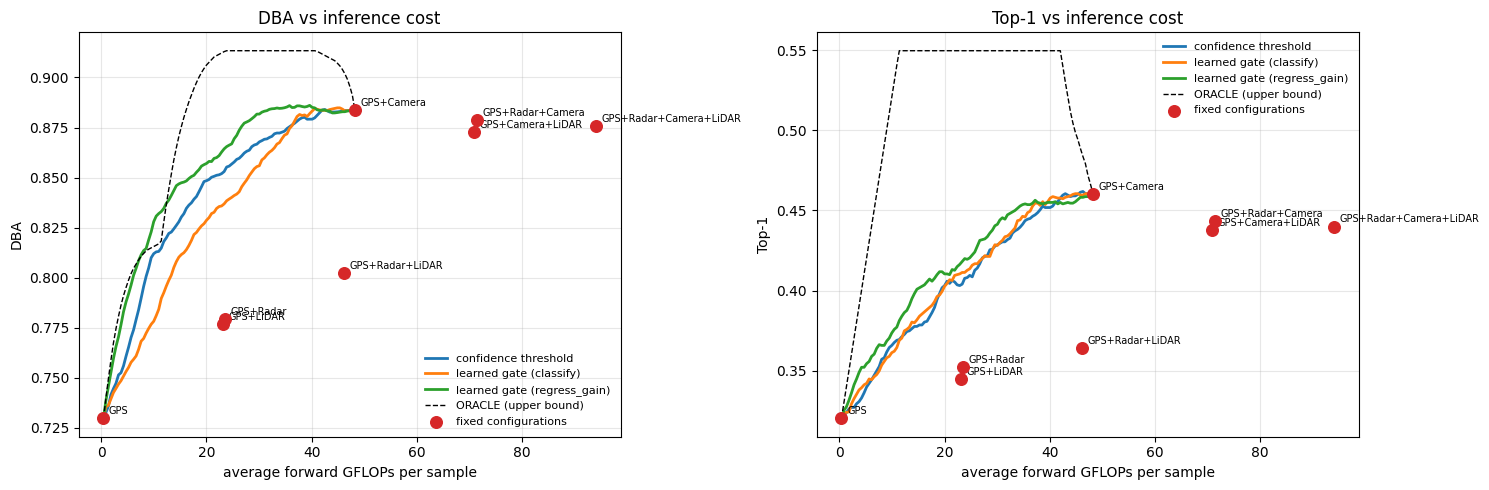

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for a, col in zip(ax, ("DBA", "Top-1")):
    for name, g in curves.groupby("gate", sort=False):
        style = {"ls": "--", "color": "k", "lw": 1} if "ORACLE" in name else {"lw": 2}
        a.plot(g.GFLOPs, g[col], label=name, **style)
    fx = final[final["escalated_%"].isna()]      # the fixed configurations
    a.scatter(fx.GFLOPs, fx[col], s=70, c="tab:red", zorder=5, label="fixed configurations")
    for _, r in fx.iterrows():
        a.annotate(r.model.replace(" + ", "+"), (r.GFLOPs, r[col]), fontsize=7,
                   xytext=(4, 3), textcoords="offset points")
    a.set(xlabel="average forward GFLOPs per sample", ylabel=col,
          title=f"{col} vs inference cost")
    a.grid(alpha=.3)
    a.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(FINAL / "plots" / "accuracy_vs_cost.png", dpi=150)
plt.show()

## 6. Does the gate generalise across environments?

The ablation showed camera is excellent on seen scenarios and poor on the
unseen one, so a gate that has merely learned "be confident → use camera" would
escalate exactly wrongly off-distribution. Training on some scenarios and
evaluating on a held-out one tests for that. Scenario ID is never a feature.

In [11]:
rows = []
for held in sorted(EV.scenario.unique()):
    tr = TR[TR.scenario != held]
    te = EV[EV.scenario == held]
    if len(tr) < 100 or len(te) < 30:
        print(f"  {held}: too few samples ({len(tr)} train / {len(te)} eval), skipped")
        continue
    fn, _ = train_gate(tr[FEATS].to_numpy(), tr.gain_dba.to_numpy(), "regress")
    s = fn(te[FEATS].to_numpy())
    order = np.argsort(-s)
    for f in (0.25, 0.50):
        k = int(round(f * len(te)))
        esc = np.zeros(len(te), bool)
        esc[order[:k]] = True
        rows.append({"held_out": held, "escalated": f,
                     "DBA": float(np.where(esc, te.exp_dba, te.dba).mean()),
                     "DBA_always_cheap": float(te.dba.mean()),
                     "DBA_always_expensive": float(te.exp_dba.mean()),
                     "n": len(te)})
gen = pd.DataFrame(rows)
if len(gen):
    gen.to_csv(OUT / "cross_scenario_generalisation.csv", index=False)
    print(gen.round(4).to_string(index=False))
    print("\nIf the gate beats always-cheap on a scenario it never trained on, it has")
    print("learned something transferable rather than an environment shortcut.")

  held_out  escalated    DBA  DBA_always_cheap  DBA_always_expensive   n
scenario32       0.25 0.7409            0.6209                0.8793 600
scenario32       0.50 0.8078            0.6209                0.8793 600
scenario33       0.25 0.8115            0.7944                0.8748 750
scenario33       0.50 0.8452            0.7944                0.8748 750
scenario34       0.25 0.8265            0.7497                0.8943 848
scenario34       0.50 0.8596            0.7497                0.8943 848

If the gate beats always-cheap on a scenario it never trained on, it has
learned something transferable rather than an environment shortcut.


## 7. Save

In [12]:
meta = {"quick_run": QUICK_RUN, "cheap": CHEAP, "expensive": EXPENSIVE,
        "routes": ROUTES, "train_split": TRAIN_SPLIT, "eval_split": EVAL_SPLIT,
        "limits": {"train": LIMIT_TRAIN, "eval": LIMIT_EVAL},
        "n_features": len(FEATS), "features": FEATS,
        "gate_objectives": list(gates), "gate_parameters": npar,
        "cost_model": f"cost(f) = {C_LO} + f * ({C_HI} - {C_LO})",
        "leakage_note": "gate inputs contain no beam, power vector, or correctness "
                        "signal; those build the training target only"}
(OUT / "config.json").write_text(json.dumps(meta, indent=2))
(FINAL / "config.json").write_text(json.dumps(meta, indent=2))
for d in (OUT, FINAL):
    for p in sorted(d.rglob("*")):
        if p.is_file():
            print(f"  {p}  ({p.stat().st_size/1e3:.1f} KB)")

  /kaggle/working/outputs/adaptive_gate/config.json  (1.2 KB)
  /kaggle/working/outputs/adaptive_gate/cross_scenario_generalisation.csv  (0.5 KB)
  /kaggle/working/outputs/adaptive_gate/operating_curves.csv  (34.0 KB)
  /kaggle/working/outputs/adaptive_gate/table_train.csv  (3445.9 KB)
  /kaggle/working/outputs/adaptive_gate/table_train_quick.csv  (156.4 KB)
  /kaggle/working/outputs/adaptive_gate/table_val.csv  (864.0 KB)
  /kaggle/working/outputs/adaptive_gate/table_val_quick.csv  (118.3 KB)
  /kaggle/working/outputs/adaptive_final/config.json  (1.2 KB)
  /kaggle/working/outputs/adaptive_final/final_comparison.csv  (1.4 KB)
  /kaggle/working/outputs/adaptive_final/plots/accuracy_vs_cost.png  (197.6 KB)
